In [1]:
%pip install ipywidgets

Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

# Disable the C-linker to avoid the relocation/linkage error.
# This will use the Python backend. For 1-property sampling, 
# the performance hit is negligible.
os.environ["PYTENSOR_FLAGS"] = "cxx=,linker=py"

import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Load the generated dataset
df = pd.read_csv("../data/london_rentals_fix_params.csv")

# --- 1. DEFINING THE "TRUTH" (From your generation script) ---
INTERCEPT = 7.5
BETA_ROOM = 0.15
BETA_DIST = -0.05
BETA_UNDERGROUND = 0.10
SIGMA = 0.1  # The market noise/volatility
AGENT_PREMIUM = 0.15

# Mappings for categorical logic
TYPE_MAP = {'House': 0.2, 'Flat': 0.0}
OUTDOOR_MAP = {'Garden': 0.15, 'Terrace': 0.1, 'Balcony': 0.05, 'Nothing': 0.0}

# --- 2. FEATURE ENGINEERING ---
# We transform everything into log-space because the math is additive there.
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# Calculate the "Intrinsic Value" of the property (everything except the Agent markup)
# This is our mu (mean) for the 'Owner' hypothesis.
df['expected_log_rent_base'] = (
    INTERCEPT + 
    (df['n_rooms'] * BETA_ROOM) +
    (df['dist_centre_km'] * BETA_DIST) +
    (df['near_underground'] * BETA_UNDERGROUND) +
    df['property_type'].map(TYPE_MAP) +
    df['outdoor_space'].map(OUTDOOR_MAP)
)

print(f"Dataset loaded. Total properties: {len(df)}")
print(f"Reference Sigma: {SIGMA} (approx {SIGMA*100}% price fluctuation)")
df[['monthly_rent_gbp', 'log_rent', 'expected_log_rent_base']].head()

Dataset loaded. Total properties: 1000
Reference Sigma: 0.1 (approx 10.0% price fluctuation)


,monthly_rent_gbp,log_rent,expected_log_rent_base
0,3102.955547,8.040110,7.990439
1,3157.070671,8.057400,8.071226
2,3667.633778,8.207302,8.142533
3,4132.482893,8.326634,8.174331
4,1771.819406,7.479762,7.503178


In [3]:
# --- BAYESIAN LIKELIHOOD CALCULATION ---

"""
LOGIC:
Our generative model defined price as: 
    ln(Price) = expected_log_rent + Noise(0, sigma^2)

To perform inference, we calculate the 'Likelihood'—the probability of observing 
the actual rent given a specific hypothesis (Owner vs. Agent). 

MATH:
If the noise is Gaussian, the likelihood follows the Normal PDF:
    P(Data | Hypothesis) = (1 / (σ * sqrt(2π))) * exp(-0.5 * ((x - μ) / σ)^2)

Where:
    x = The observed 'log_rent'
    μ = Our calculated 'expected_log_rent_base' (plus premium if Agent)
    σ = The 'SIGMA' (0.1) representing market volatility
"""

# Hypothesis A: The property is an Owner listing (No Premium)
# Here, μ = expected_log_rent_base
df['likelihood_owner'] = stats.norm.pdf(
    df['log_rent'], 
    loc=df['expected_log_rent_base'], 
    scale=SIGMA
)

# Hypothesis B: The property is an Agent listing (Includes +0.15 Premium)
# Here, μ = expected_log_rent_base + 0.15
df['likelihood_agent'] = stats.norm.pdf(
    df['log_rent'], 
    loc=df['expected_log_rent_base'] + AGENT_PREMIUM, 
    scale=SIGMA
)

# Preview the results
print("Likelihoods calculated based on Normal PDF of residuals.")
df[['monthly_rent_gbp', 'listing_type', 'likelihood_owner', 'likelihood_agent']].head()

Likelihoods calculated based on Normal PDF of residuals.


,monthly_rent_gbp,listing_type,likelihood_owner,likelihood_agent
0,3102.955547,Owner,3.526423,2.411756
1,3157.070671,Owner,3.951472,1.042573
2,3667.633778,Owner,3.234571,2.774385
3,4132.482893,Owner,1.250867,3.988365
4,1771.819406,Owner,3.881543,0.886923


In [4]:
# --- MODEL COMPARISON: POSTERIOR ODDS RATIO ---

# 1. Calculate the Bayes Factor (Likelihood Ratio)
# How much better does the Agent model explain the price than the Owner model?
df['bayes_factor'] = df['likelihood_agent'] / df['likelihood_owner']

# 2. Prior Odds (0.5 / 0.5 = 1)
prior_odds = 1.0

# 3. Posterior Odds Ratio
df['posterior_odds'] = df['bayes_factor'] * prior_odds

# 4. Decision Logic
# Ratio > 1 -> Evidence favors Agent
# Ratio < 1 -> Evidence favors Owner
print("Odds Ratios calculated. Evidence check:")
df[['monthly_rent_gbp', 'listing_type', 'bayes_factor', 'posterior_odds']].head(10)

Odds Ratios calculated. Evidence check:


,monthly_rent_gbp,listing_type,bayes_factor,posterior_odds
0,3102.955547,Owner,0.683910,0.683910
1,3157.070671,Owner,0.263844,0.263844
2,3667.633778,Owner,0.857729,0.857729
3,4132.482893,Owner,3.188481,3.188481
4,1771.819406,Owner,0.228497,0.228497
5,4523.793073,Owner,0.228503,0.228503
6,3011.560738,Owner,3.468836,3.468836
7,3277.097326,Owner,1.026497,1.026497
8,1665.001388,Owner,0.160540,0.160540
9,3251.304470,Owner,0.732597,0.732597


In [5]:
# --- ACCURACY EVALUATION ---

# 1. The Decision: Pick the model with the higher odds
df['predicted_type'] = np.where(df['posterior_odds'] > 1, 'Agent', 'Owner')

# 2. Check if the prediction matches the ground truth
df['is_correct'] = df['predicted_type'] == df['listing_type']

# 3. Calculate overall accuracy percentage
accuracy = df['is_correct'].mean() * 100

print(f"--- Model Accuracy: {accuracy:.2f}% ---")

# 4. Breakdown by class (Confusion Matrix)
print("\nPrediction Breakdown:")
print(pd.crosstab(df['listing_type'], df['predicted_type']))

--- Model Accuracy: 78.20% ---

Prediction Breakdown:
predicted_type  Agent  Owner
listing_type                
Agent             391    109
Owner             109    391


We now consider the more complicated case where the parameters in the likelihood are free to vary.

In [6]:
import pymc as pm  # This is our MCMC sampler
import arviz as az # For visualizing posterior distributions

# Load the NEW dataset with random parameters
df = pd.read_csv("../data/london_rentals_rand_params.csv")

# --- 1. SETTING OUR HYPER-PRIORS ---
# These reflect the means of the distributions we used in gen_prop_data.py
# In a real-world scenario, these would be based on historical market data.
VOLATILITY = 0.03  # Our 'Market Volatility' from the generation script

# Mappings for categorical logic (used to prepare the data for PyMC)
df['is_house'] = df['property_type'].map({'House': 1, 'Flat': 0})
df['has_garden'] = (df['outdoor_space'] == 'Garden').astype(int)
df['has_terrace'] = (df['outdoor_space'] == 'Terrace').astype(int)
df['has_balcony'] = (df['outdoor_space'] == 'Balcony').astype(int)

# --- 2. FEATURE ENGINEERING ---
df['log_rent'] = np.log(df['monthly_rent_gbp'])

# We still calculate a 'baseline' expected rent using the means for comparison,
# but the MCMC model will treat these coefficients as flexible distributions.
# Reference means from our non-Gaussian generation script
INTERCEPT_MU = 7.5
ROOM_MU      = 0.15
DIST_MU      = -0.05
UNDER_MU     = 0.10
HOUSE_MU     = 0.20
GARDEN_MU    = 0.15
TERRACE_MU   = 0.10
BALCONY_MU   = 0.05

df['expected_log_rent_fixed_ref'] = (
    INTERCEPT_MU + 
    (df['n_rooms'] * ROOM_MU) + 
    (df['dist_centre_km'] * DIST_MU) + 
    (df['near_underground'] * UNDER_MU) +
    (df['is_house'] * HOUSE_MU) +
    (df['has_garden'] * GARDEN_MU) +
    (df['has_terrace'] * TERRACE_MU) +
    (df['has_balcony'] * BALCONY_MU)
)

print(f"Dataset loaded: {len(df)} properties.")
print(f"Likelihood assumption: Agent premium follows a Gamma distribution.")
print(f"Likelihood assumption: Room value follows a Laplace distribution.")
df[['monthly_rent_gbp', 'log_rent', 'expected_log_rent_fixed_ref']].head()

Dataset loaded: 1000 properties.
Likelihood assumption: Agent premium follows a Gamma distribution.
Likelihood assumption: Room value follows a Laplace distribution.


,monthly_rent_gbp,log_rent,expected_log_rent_fixed_ref
0,3482.235341,8.155430,7.990439
1,3448.296661,8.145636,8.071226
2,5188.841209,8.554266,8.142533
3,5241.364385,8.564337,8.174331
4,2119.278223,7.658831,7.503178


In [ ]:
import pymc as pm
import arviz as az

# 1. SELECT THE TEST PROPERTY
# We pick one property from our dataset to perform the 'Injection Test'
idx = 0  # Change this index to test different properties
test_prop = df.iloc[idx]
y_obs = test_prop['log_rent']

print(f"Testing Property ID: {test_prop.get('id', idx)}")
print(f"Observed Log Price: {y_obs:.4f}")
print(f"True Listing Type: {test_prop['listing_type']}")
print("-" * 30)

def run_model_selection(y, prop_data, mc_draws=100, is_agent_hyp=False):
    """
    Computes the Log-Evidence (log Z) for a specific hypothesis using SMC.
    
    Parameters:
    -----------
    y : float (Observed log-rent)
    prop_data : Series (Row containing n_rooms, dist_km, etc.)
    is_agent_hyp : bool (If True, adds the Agent Premium to the model)
    """
    
    with pm.Model() as model:
        # --- PRIORS: Based on our injection distributions ---
        # Note: We use the population-level means and volatility (0.03)
        vol = 0.03
        
        # Market intercept and slopes (Gaussian)
        intercept = pm.Normal("intercept", mu=7.5, sigma=vol)
        beta_dist = pm.Normal("beta_dist", mu=-0.05, sigma=vol)
        beta_under = pm.Normal("beta_under", mu=0.10, sigma=vol)
        
        # Structural features (Gaussian)
        beta_house = pm.Normal("beta_house", mu=0.20, sigma=vol)
        beta_garden = pm.Normal("beta_garden", mu=0.15, sigma=vol)
        beta_terrace = pm.Normal("beta_terrace", mu=0.10, sigma=vol)
        beta_balcony = pm.Normal("beta_balcony", mu=0.05, sigma=vol)
        
        # Room impact (Laplace - fat-tailed, just like our injection)
        beta_room = pm.Laplace("beta_room", mu=0.15, b=vol)
        
        # --- AGENT PREMIUM LOGIC ---
        premium = 0
        if is_agent_hyp:
            # Matches np.random.gamma(shape=5.0, scale=0.15/5.0)
            premium = pm.Gamma("premium", alpha=5.0, beta=5.0/0.15)
        
        # --- THE FORWARD MODEL ---
        # Calculation of the 'theoretical' price for this specific property
        mu = (
            intercept +
            (prop_data['n_rooms'] * beta_room) +
            (prop_data['dist_centre_km'] * beta_dist) +
            (prop_data['near_underground'] * beta_under) +
            (prop_data['is_house'] * beta_house) +
            (prop_data['has_garden'] * beta_garden) +
            (prop_data['has_terrace'] * beta_terrace) +
            (prop_data['has_balcony'] * beta_balcony) +
            premium
        )
        
        # --- LIKELIHOOD: The Noise Profile ---
        # We know the noise is Student-T with 5 degrees of freedom and sigma=0.1
        # This matches: noise = np.random.standard_t(df=5) * 0.1
        pm.StudentT("obs", nu=5, mu=mu, sigma=0.1, observed=y)
        
        # --- MARGINAL LIKELIHOOD ESTIMATION ---
        # SMC is ideal for evidence calculation. 'draws' controls precision.
        trace = pm.sample_smc(
            draws=mc_draws, 
            chains=4, 
            progressbar=True,
            return_inferencedata=True,
        )
        
        return trace

# 2. COMPUTE LOG-EVIDENCE FOR BOTH MODELS
# In PyMC 5, Log Z is stored in the sample_stats of the first chain
# We take the mean across chains if multiple chains are used
mc_draws = 1000
print("Calculating Evidence for Owner Model...")
owner = run_model_selection(y_obs, test_prop, mc_draws=mc_draws, is_agent_hyp=False)
log_z_owner = owner.sample_stats.log_marginal_likelihood.mean().item()

print("Calculating Evidence for Agent Model...")
agent = run_model_selection(y_obs, test_prop, mc_draws=mc_draws, is_agent_hyp=True)
log_z_agent = agent.sample_stats.log_marginal_likelihood.mean().item()

# 3. INTERPRETATION
log_BF = log_z_agent - log_z_owner
BF = np.exp(log_BF)

print("\n--- RESULTS ---")
print(f"Log Z (Owner): {log_z_owner:.4f}")
print(f"Log Z (Agent): {log_z_agent:.4f}")
print(f"Bayes Factor (K): {BF:.4f}")

if BF > 10:
    print("Conclusion: Strong Evidence for AGENT model.")
elif BF < 0.1:
    print("Conclusion: Strong Evidence for OWNER model.")
else:
    print("Conclusion: Ambiguous Evidence (Inconclusive).")

Testing Property ID: 0
Observed Log Price: 8.1554
True Listing Type: Owner
------------------------------
Calculating Evidence for Owner Model...


Initializing SMC sampler...


Sampling 4 chains sequentially


Output()

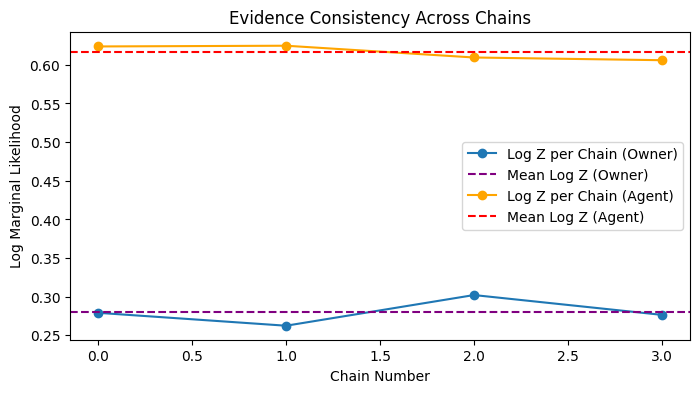

In [ ]:
# Access the log_marginal_likelihood per chain
# This shows if all 4 chains reached roughly the same conclusion
log_z_per_chain_owner = owner.sample_stats.log_marginal_likelihood.values
log_z_per_chain_agent = agent.sample_stats.log_marginal_likelihood.values

plt.figure(figsize=(8, 4))
plt.plot(log_z_per_chain_owner, 'o-', label='Log Z per Chain (Owner)')
plt.axhline(log_z_per_chain_owner.mean(), color='purple', linestyle='--', label='Mean Log Z (Owner)')
plt.plot(log_z_per_chain_agent, 'o-', color='orange', label='Log Z per Chain (Agent)')
plt.axhline(log_z_per_chain_agent.mean(), color='r', linestyle='--', label='Mean Log Z (Agent)')
plt.xlabel('Chain Number')
plt.ylabel('Log Marginal Likelihood')
plt.title('Evidence Consistency Across Chains')
plt.legend()
plt.show()

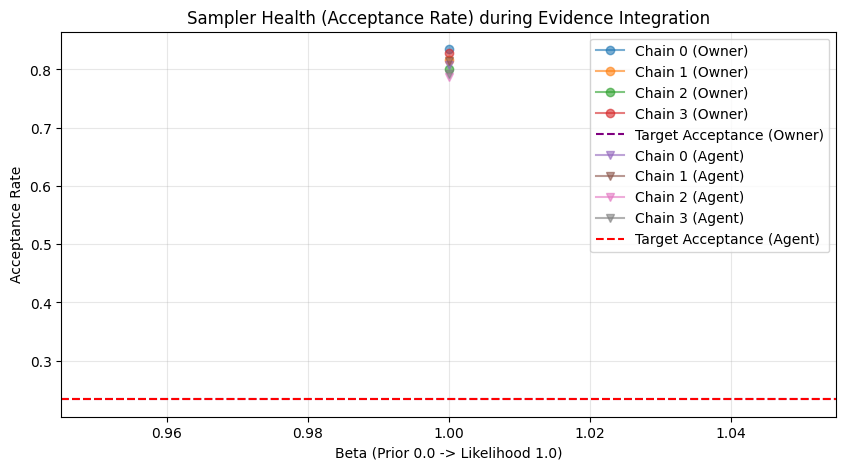

In [ ]:
# Accessing the available variables from your KeyError list
accept_rates_owner = owner.sample_stats["accept_rate"].values
betas_owner = owner.sample_stats["beta"].values
accept_rates_agent = agent.sample_stats["accept_rate"].values
betas_agent = agent.sample_stats["beta"].values

plt.figure(figsize=(10, 5))

# Plotting the acceptance rate across stages
# Note: In SMC, 'draw' index usually corresponds to the stage index here
for i in range(accept_rates_owner.shape[0]):
    plt.plot(betas_owner[i], accept_rates_owner[i], 'o-', alpha=0.6, label=f'Chain {i} (Owner)')
plt.axhline(y=0.234, color='purple', linestyle='--', label='Target Acceptance (Owner)')
for i in range(accept_rates_agent.shape[0]):
    plt.plot(betas_agent[i], accept_rates_agent[i], 'v-', alpha=0.6, label=f'Chain {i} (Agent)')
plt.axhline(y=0.234, color='r', linestyle='--', label='Target Acceptance (Agent)')
plt.xlabel('Beta (Prior 0.0 -> Likelihood 1.0)')
plt.ylabel('Acceptance Rate')
plt.title('Sampler Health (Acceptance Rate) during Evidence Integration')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

OWNER



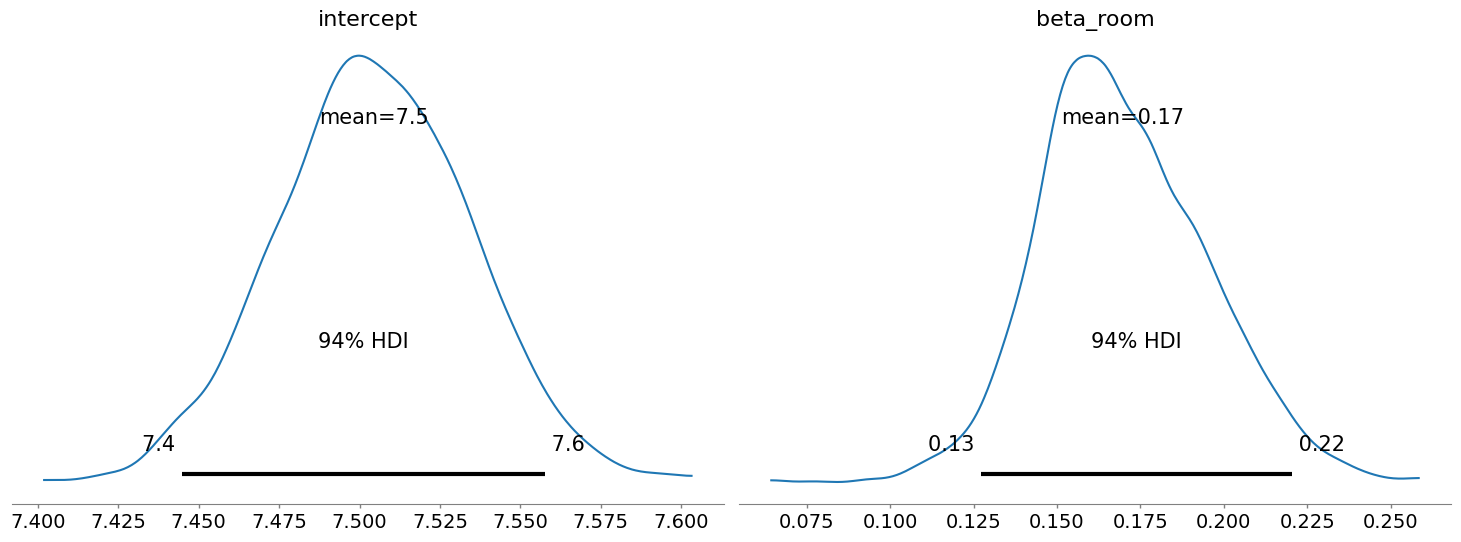

AGENT



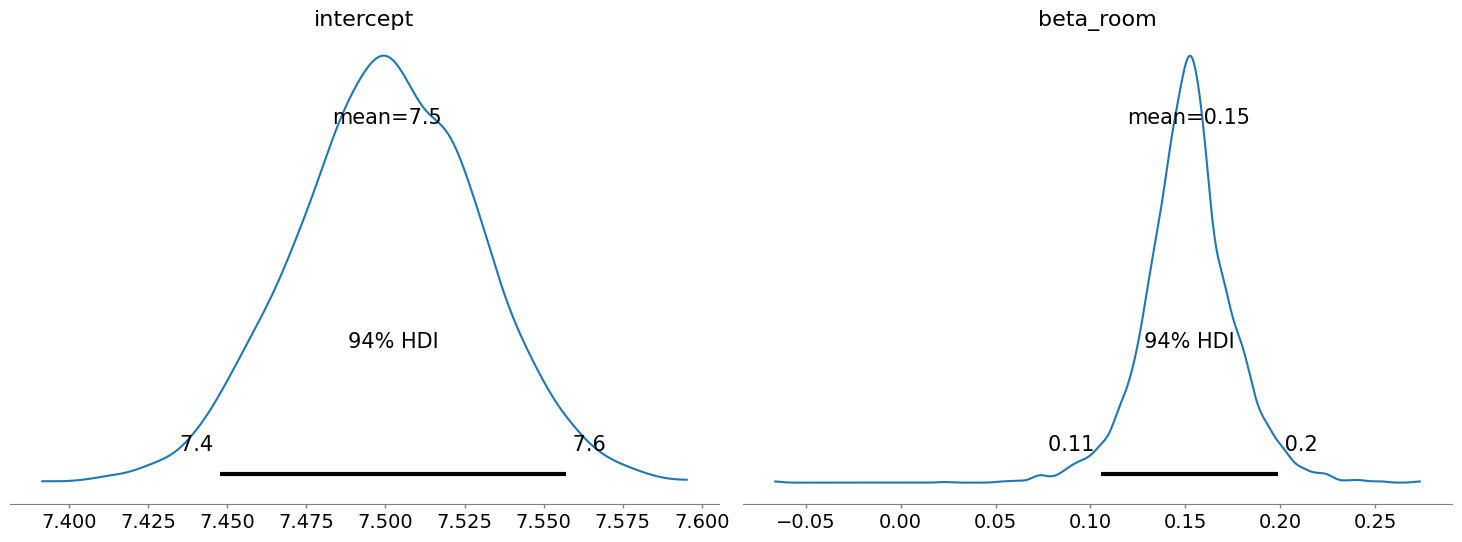

In [ ]:
# Plot the distribution of the parameters after seeing the data
print("OWNER")
print("")
az.plot_posterior(owner, var_names=['intercept', 'beta_room'])
plt.tight_layout()
plt.show()

print("AGENT")
print("")
az.plot_posterior(agent, var_names=['intercept', 'beta_room'])
plt.tight_layout()
plt.show()

Sampling: [obs]


Output()

Sampling: [obs]


Output()

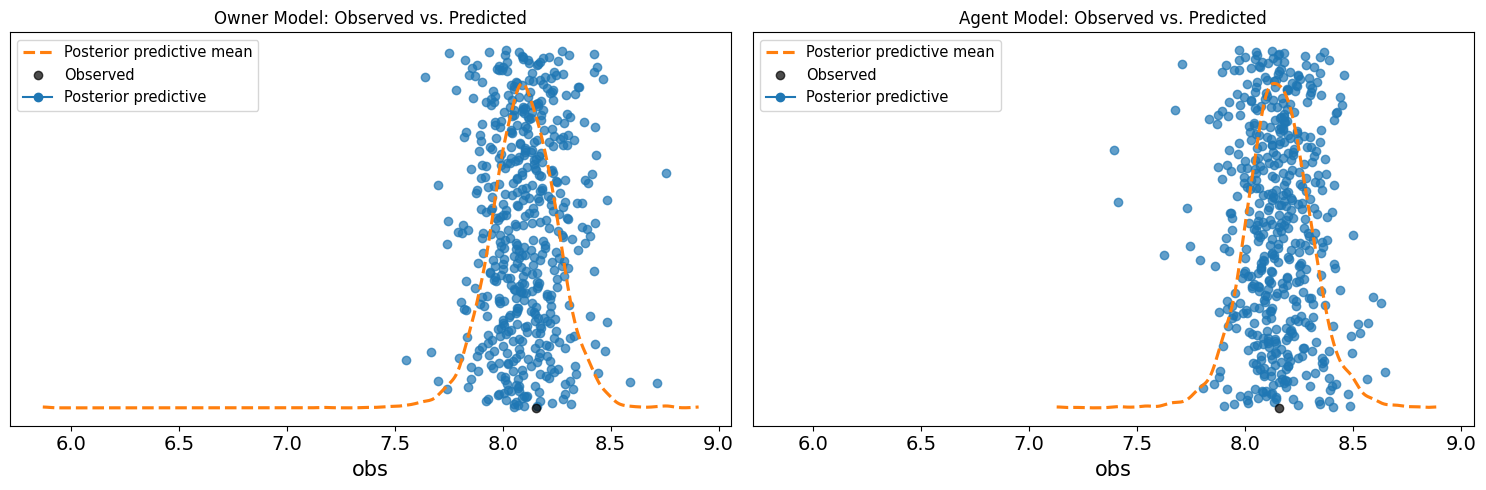

In [ ]:
# --- POSTERIOR PREDICTIVE CHECK (OWNER) ---
with pm.Model() as owner_model:
    vol = 0.03
    intercept = pm.Normal("intercept", mu=7.5, sigma=vol)
    beta_dist = pm.Normal("beta_dist", mu=-0.05, sigma=vol)
    beta_under = pm.Normal("beta_under", mu=0.10, sigma=vol)
    beta_house = pm.Normal("beta_house", mu=0.20, sigma=vol)
    beta_garden = pm.Normal("beta_garden", mu=0.15, sigma=vol)
    beta_terrace = pm.Normal("beta_terrace", mu=0.10, sigma=vol)
    beta_balcony = pm.Normal("beta_balcony", mu=0.05, sigma=vol)
    beta_room = pm.Laplace("beta_room", mu=0.15, b=vol)
    
    mu = (intercept + (test_prop['n_rooms'] * beta_room) + 
          (test_prop['dist_centre_km'] * beta_dist) + 
          (test_prop['near_underground'] * beta_under) + 
          (test_prop['is_house'] * beta_house) + 
          (test_prop['has_garden'] * beta_garden) + 
          (test_prop['has_terrace'] * beta_terrace) + 
          (test_prop['has_balcony'] * beta_balcony))
    
    pm.StudentT("obs", nu=5, mu=mu, sigma=0.1, observed=y_obs)
    pm.sample_posterior_predictive(owner, extend_inferencedata=True)

# --- POSTERIOR PREDICTIVE CHECK (AGENT) ---
with pm.Model() as agent_model:
    vol = 0.03
    intercept = pm.Normal("intercept", mu=7.5, sigma=vol)
    beta_dist = pm.Normal("beta_dist", mu=-0.05, sigma=vol)
    beta_under = pm.Normal("beta_under", mu=0.10, sigma=vol)
    beta_house = pm.Normal("beta_house", mu=0.20, sigma=vol)
    beta_garden = pm.Normal("beta_garden", mu=0.15, sigma=vol)
    beta_terrace = pm.Normal("beta_terrace", mu=0.10, sigma=vol)
    beta_balcony = pm.Normal("beta_balcony", mu=0.05, sigma=vol)
    beta_room = pm.Laplace("beta_room", mu=0.15, b=vol)
    
    # Agent hypothesis includes the premium
    premium = pm.Gamma("premium", alpha=5.0, beta=5.0/0.15)
    
    mu = (intercept + (test_prop['n_rooms'] * beta_room) + 
          (test_prop['dist_centre_km'] * beta_dist) + 
          (test_prop['near_underground'] * beta_under) + 
          (test_prop['is_house'] * beta_house) + 
          (test_prop['has_garden'] * beta_garden) + 
          (test_prop['has_terrace'] * beta_terrace) + 
          (test_prop['has_balcony'] * beta_balcony) +
          premium)
    
    pm.StudentT("obs", nu=5, mu=mu, sigma=0.1, observed=y_obs)
    pm.sample_posterior_predictive(agent, extend_inferencedata=True)

# --- PLOTTING ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Plot Owner
az.plot_ppc(owner, kind="scatter", num_pp_samples=500, ax=axes[0])
axes[0].set_title("Owner Model: Observed vs. Predicted")

# Plot Agent
az.plot_ppc(agent, kind="scatter", num_pp_samples=500, ax=axes[1])
axes[1].set_title("Agent Model: Observed vs. Predicted")

plt.tight_layout()
plt.show()

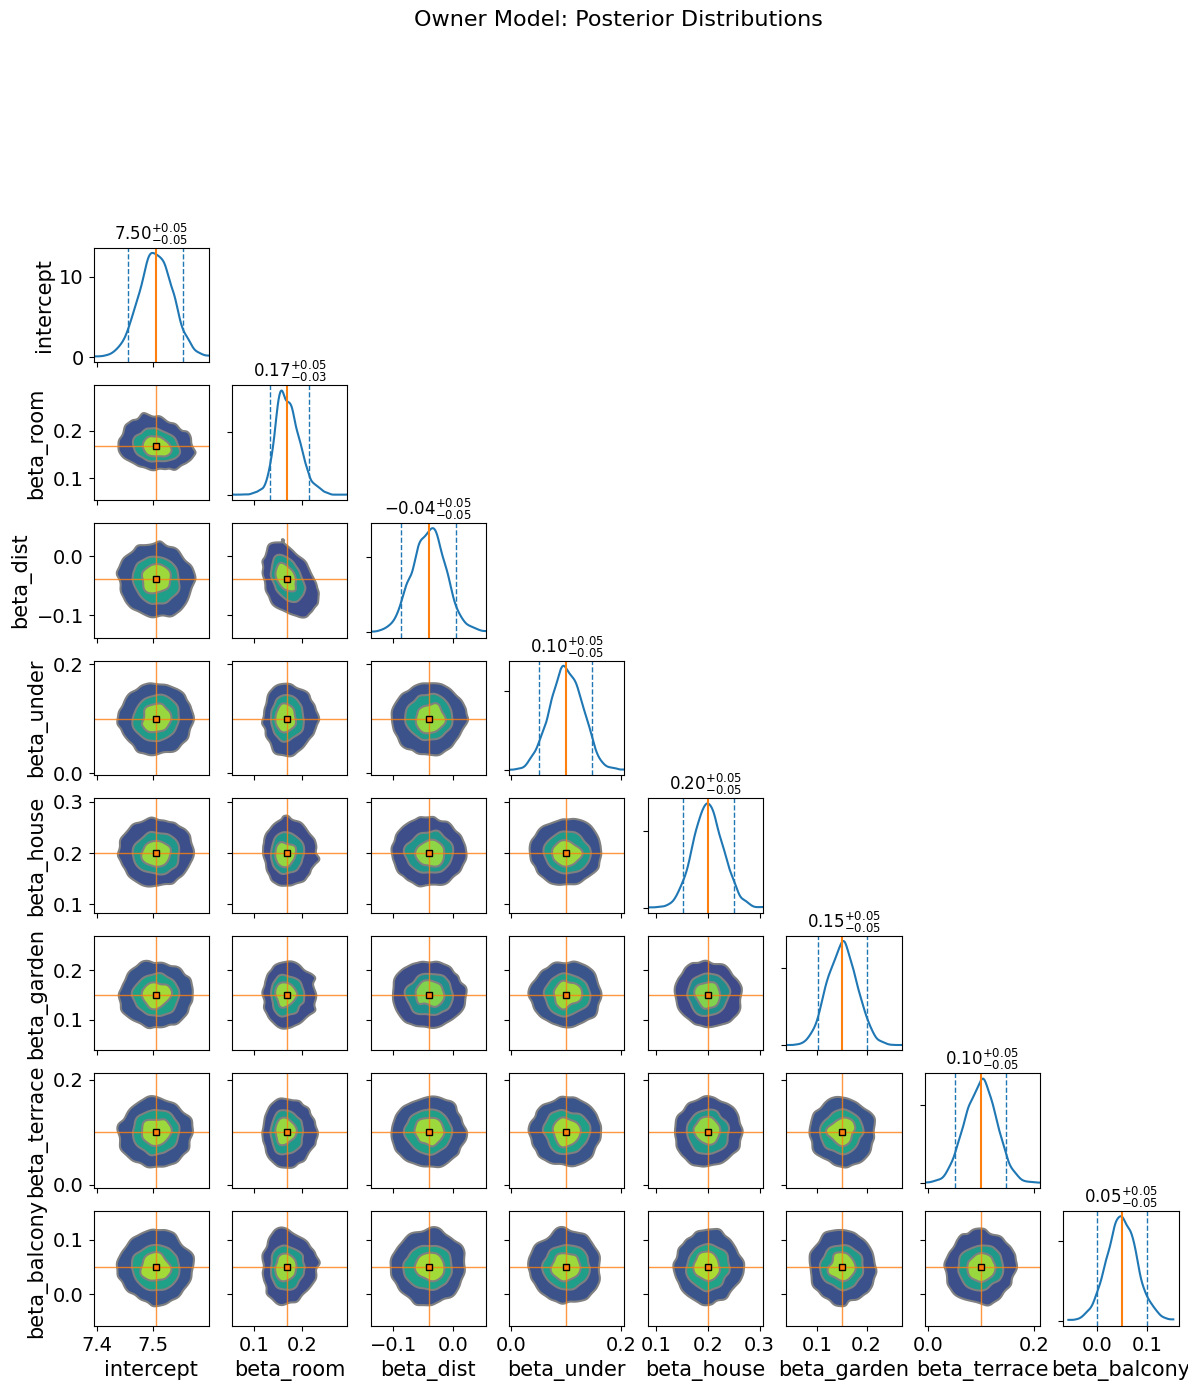

In [ ]:
# Variables for the first plot
owner_vars = [
    "intercept", "beta_room", "beta_dist", "beta_under",
    "beta_house", "beta_garden", "beta_terrace", "beta_balcony"
]

# --- 1. OWNER MODEL CORNER PLOT ---
stats_owner = {v: float(owner.posterior[v].median()) for v in owner_vars}

axes_owner = az.plot_pair(
    owner,
    var_names=owner_vars,
    kind='kde',
    marginals=True,
    reference_values=stats_owner,
    reference_values_kwargs={'color': 'C1', 'marker': 's', 'markersize': 4, 'zorder': 10},
    figsize=(14, 14),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

rows, cols = axes_owner.shape
for i in range(rows):
    for j in range(cols):
        ax = axes_owner[i, j]
        if ax is None: continue
        
        if i == j:
            var = owner_vars[i]
            data = owner.posterior[var].values.flatten()
            q_low, med, q_high = np.percentile(data, [5, 50, 95])
            ax.axvline(q_low, color='C0', linestyle='--', linewidth=1)
            ax.axvline(q_high, color='C0', linestyle='--', linewidth=1)
            ax.axvline(med, color='C1', linestyle='-', linewidth=1.5)
            upper, lower = q_high - med, med - q_low
            ax.set_title(f"${med:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=12)
        elif i > j:
            ax.axvline(stats_owner[owner_vars[j]], color='C1', linestyle='-', linewidth=1, alpha=0.8)
            ax.axhline(stats_owner[owner_vars[i]], color='C1', linestyle='-', linewidth=1, alpha=0.8)

plt.suptitle("Owner Model: Posterior Distributions", fontsize=16, y=1.02)
plt.show()


# --- 2. AGENT MODEL CORNER PLOT ---
# Added "premium" variable
agent_vars = owner_vars + ["premium"]
stats_agent = {v: float(agent.posterior[v].median()) for v in agent_vars}

axes_agent = az.plot_pair(
    agent,
    var_names=agent_vars,
    kind='kde',
    marginals=True,
    reference_values=stats_agent,
    reference_values_kwargs={'color': 'C1', 'marker': 's', 'markersize': 4, 'zorder': 10},
    figsize=(14, 14),
    kde_kwargs={"hdi_probs": [0.3, 0.6, 0.9]}
)

rows, cols = axes_agent.shape
for i in range(rows):
    for j in range(cols):
        ax = axes_agent[i, j]
        if ax is None: continue
        
        if i == j:
            var = agent_vars[i]
            data = agent.posterior[var].values.flatten()
            q_low, med, q_high = np.percentile(data, [5, 50, 95])
            ax.axvline(q_low, color='C0', linestyle='--', linewidth=1)
            ax.axvline(q_high, color='C0', linestyle='--', linewidth=1)
            ax.axvline(med, color='C1', linestyle='-', linewidth=1.5)
            upper, lower = q_high - med, med - q_low
            ax.set_title(f"${med:.2f}^{{+{upper:.2f}}}_{{-{lower:.2f}}}$", fontsize=12)
        elif i > j:
            ax.axvline(stats_agent[agent_vars[j]], color='C1', linestyle='-', linewidth=1, alpha=0.8)
            ax.axhline(stats_agent[agent_vars[i]], color='C1', linestyle='-', linewidth=1, alpha=0.8)

plt.suptitle("Agent Model: Posterior Distributions", fontsize=16, y=1.02)
plt.show()

In [ ]:
# Focus only on the main slopes and intercept
print("OWNER")
print("")
stats = az.summary(owner, var_names=["intercept", "beta_room", "beta_dist"])
print(stats)

print("AGENT")
print("")
stats = az.summary(agent, var_names=["intercept", "beta_room", "beta_dist"])
print(stats)

            mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
intercept  7.504  0.029   7.450    7.560        0.0      0.0    3999.0   
beta_room  0.170  0.026   0.126    0.220        0.0      0.0    3801.0   
beta_dist -0.041  0.028  -0.095    0.011        0.0      0.0    3964.0   

           ess_tail  r_hat  
intercept    3685.0    1.0  
beta_room    3802.0    1.0  
beta_dist    3932.0    1.0  
